# **Facial Emotion Recognition using Deep Learning**

# Stage 2: Model Training and Evaluation

---



# ===== 1. DATA PREPARATION =====
## Imports and Environment Setup. Datasets Loading.


In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import random
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import precision_recall_fscore_support



In [2]:
!git clone https://github.com/tomaes1987/facerecogniction.git


fatal: destination path 'facerecogniction' already exists and is not an empty directory.


In [3]:
%cd facerecogniction


/content/facerecogniction


In [4]:
!ls datasets
!ls datasets/balanced/train
!ls datasets/original/val



balanced  original
angry  disgust	fear  happy  neutral  sad  surprise
angry  disgust	fear  happy  neutral  sad  surprise


In [5]:
print(tf.__version__)


2.19.0


In [6]:
IMG_SIZE = 48
BATCH_SIZE = 64
NUM_CLASSES = 7
EPOCHS = 50

In [7]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    "datasets/balanced/train",
    image_size=(IMG_SIZE, IMG_SIZE),
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True
)


Found 43710 files belonging to 7 classes.


In [8]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    "datasets/original/val",
    image_size=(IMG_SIZE, IMG_SIZE),
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)


Found 3657 files belonging to 7 classes.


In [9]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    "datasets/original/test",
    image_size=(IMG_SIZE, IMG_SIZE),
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)


Found 7178 files belonging to 7 classes.


In [10]:
normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))


# ===== 2. MODEL TRAINING =====
## Baseline CNN Model


In [11]:
model = models.Sequential([

    layers.Input(shape=(48,48,1)),
    layers.Conv2D(32, (3,3), activation='relu', padding='same',
              kernel_regularizer=regularizers.l2(0.001)),

    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu', padding='same',
                  kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu', padding='same',
                  kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(256, (3,3), activation='relu', padding='same',
                  kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(NUM_CLASSES, activation='softmax')
])


In [12]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 6, 6, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 6, 6, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 981,639 (3.74 MB)

 Trainable params: 980,679 (3.74 MB)

 Non-trainable params: 960 (3.75 KB)

### CNN Compilation


In [13]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


In [14]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        patience=5,
        factor=0.3
    )
]



### CNN Training


In [15]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=callbacks
)


Epoch 1/50
683/683 ━━━━━━━━━━━━━━━━━━━━ 23s 23ms/step - accuracy: 0.2376 - loss: 2.3407 - val_accuracy: 0.3722 - val_loss: 1.8113 - learning_rate: 0.0010
Epoch 2/50
683/683 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.3701 - loss: 1.8218 - val_accuracy: 0.4271 - val_loss: 1.6764 - learning_rate: 0.0010
Epoch 3/50
683/683 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.4235 - loss: 1.6796 - val_accuracy: 0.4709 - val_loss: 1.5676 - learning_rate: 0.0010
Epoch 4/50
683/683 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.4641 - loss: 1.6002 - val_accuracy: 0.4635 - val_loss: 1.6108 - learning_rate: 0.0010
Epoch 5/50
683/683 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.4934 - loss: 1.5442 - val_accuracy: 0.5206 - val_loss: 1.4960 - learning_rate: 0.0010
Epoch 6/50
683/683 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.5110 - loss: 1.5264 - val_accuracy: 0.5026 - val_loss: 1.5693 - learning_rate: 0.0010
Epoch 7/50
683/683 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.5294 - loss: 

## Saving Trained Models


In [16]:
model.save("cnn_baseline.keras")


In [17]:
IMG_SIZE_TL = 224
BATCH_SIZE = 64
NUM_CLASSES = 7
EPOCHS = 30

In [18]:
train_ds_tl = tf.keras.utils.image_dataset_from_directory(
    "datasets/balanced/train",
    image_size=(IMG_SIZE_TL, IMG_SIZE_TL),
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True
)


Found 43710 files belonging to 7 classes.


In [19]:
val_ds_tl = tf.keras.utils.image_dataset_from_directory(
    "datasets/original/val",
    image_size=(IMG_SIZE_TL, IMG_SIZE_TL),
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)


Found 3657 files belonging to 7 classes.


In [39]:
test_ds_tl = tf.keras.utils.image_dataset_from_directory(
    "datasets/original/test",
    image_size=(IMG_SIZE_TL, IMG_SIZE_TL),
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

test_ds_tl = test_ds_tl.map(preprocess_tl)


Found 7178 files belonging to 7 classes.


In [20]:
def preprocess_tl(x, y):
    x = tf.image.grayscale_to_rgb(x)
    x = preprocess_input(x)
    return x, y

train_ds_tl = train_ds_tl.map(preprocess_tl)
val_ds_tl = val_ds_tl.map(preprocess_tl)

## Transfer Learning - MobileNetV2


In [21]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE_TL, IMG_SIZE_TL, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False


In [22]:
model_tl = tf.keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(NUM_CLASSES, activation="softmax")
])


In [23]:
model_tl.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,855 (9.24 MB)

 Trainable params: 164,871 (644.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### TL Compilation


In [24]:
model_tl.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


In [25]:
callbacks_tl = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=7,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        patience=3,
        factor=0.3
    )
]


### TL Training (Frozen Backbone)


In [26]:
history_tl = model_tl.fit(
    train_ds_tl,
    validation_data=val_ds_tl,
    epochs=EPOCHS,
    callbacks=callbacks_tl
)


Epoch 1/30
683/683 ━━━━━━━━━━━━━━━━━━━━ 99s 120ms/step - accuracy: 0.3357 - loss: 1.7175 - val_accuracy: 0.4769 - val_loss: 1.3922 - learning_rate: 0.0010
Epoch 2/30
683/683 ━━━━━━━━━━━━━━━━━━━━ 56s 82ms/step - accuracy: 0.4426 - loss: 1.4733 - val_accuracy: 0.4969 - val_loss: 1.3311 - learning_rate: 0.0010
Epoch 3/30
683/683 ━━━━━━━━━━━━━━━━━━━━ 82s 83ms/step - accuracy: 0.4668 - loss: 1.4069 - val_accuracy: 0.5045 - val_loss: 1.3171 - learning_rate: 0.0010
Epoch 4/30
683/683 ━━━━━━━━━━━━━━━━━━━━ 56s 81ms/step - accuracy: 0.4840 - loss: 1.3616 - val_accuracy: 0.5105 - val_loss: 1.3043 - learning_rate: 0.0010
Epoch 5/30
683/683 ━━━━━━━━━━━━━━━━━━━━ 56s 83ms/step - accuracy: 0.5025 - loss: 1.3282 - val_accuracy: 0.5103 - val_loss: 1.3086 - learning_rate: 0.0010
Epoch 6/30
683/683 ━━━━━━━━━━━━━━━━━━━━ 81s 81ms/step - accuracy: 0.5058 - loss: 1.3024 - val_accuracy: 0.5171 - val_loss: 1.2862 - learning_rate: 0.0010
Epoch 7/30
683/683 ━━━━━━━━━━━━━━━━━━━━ 57s 83ms/step - accuracy: 0.5115 - 

## Saving Trained Models


In [27]:
model_tl.save("mobilenet_frozen.keras")


## Fine-Tuning MobileNetV2


In [28]:
base_model.trainable = True

for layer in base_model.layers[:-25]:
    layer.trainable = False


In [29]:
model_tl.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


In [30]:
callbacks_ft = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        patience=2,
        factor=0.3
    )
]


### Fine-Tuning Training


In [31]:
history_ft = model_tl.fit(
    train_ds_tl,
    validation_data=val_ds_tl,
    epochs=15,
    callbacks=callbacks_ft
)


Epoch 1/15
683/683 ━━━━━━━━━━━━━━━━━━━━ 104s 129ms/step - accuracy: 0.4412 - loss: 1.5208 - val_accuracy: 0.4785 - val_loss: 1.8405 - learning_rate: 1.0000e-04
Epoch 2/15
683/683 ━━━━━━━━━━━━━━━━━━━━ 107s 89ms/step - accuracy: 0.5990 - loss: 1.0564 - val_accuracy: 0.5524 - val_loss: 1.2989 - learning_rate: 1.0000e-04
Epoch 3/15
683/683 ━━━━━━━━━━━━━━━━━━━━ 61s 89ms/step - accuracy: 0.6685 - loss: 0.8659 - val_accuracy: 0.5734 - val_loss: 1.2882 - learning_rate: 1.0000e-04
Epoch 4/15
683/683 ━━━━━━━━━━━━━━━━━━━━ 61s 89ms/step - accuracy: 0.7296 - loss: 0.7038 - val_accuracy: 0.5286 - val_loss: 1.5187 - learning_rate: 1.0000e-04
Epoch 5/15
683/683 ━━━━━━━━━━━━━━━━━━━━ 61s 89ms/step - accuracy: 0.7817 - loss: 0.5750 - val_accuracy: 0.5480 - val_loss: 1.5208 - learning_rate: 1.0000e-04
Epoch 6/15
683/683 ━━━━━━━━━━━━━━━━━━━━ 61s 90ms/step - accuracy: 0.8356 - loss: 0.4374 - val_accuracy: 0.5849 - val_loss: 1.4314 - learning_rate: 3.0000e-05
Epoch 7/15
683/683 ━━━━━━━━━━━━━━━━━━━━ 61s 90ms/

## Saving Trained Models


In [32]:
model_tl.save("mobilenet_finetuned_final.keras")


In [33]:
loss = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)


## CNN with Label Smoothing


In [34]:
loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=loss_fn,
    metrics=["accuracy"]
)


### CNN + Label Smoothing Training


In [35]:
history_ls = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=callbacks
)


Epoch 1/50
683/683 ━━━━━━━━━━━━━━━━━━━━ 21s 21ms/step - accuracy: 0.6117 - loss: 1.5874 - val_accuracy: 0.5250 - val_loss: 1.6928 - learning_rate: 0.0010
Epoch 2/50
683/683 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.6179 - loss: 1.5263 - val_accuracy: 0.5480 - val_loss: 1.6417 - learning_rate: 0.0010
Epoch 3/50
683/683 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.6272 - loss: 1.5128 - val_accuracy: 0.5113 - val_loss: 1.7434 - learning_rate: 0.0010
Epoch 4/50
683/683 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.6327 - loss: 1.5007 - val_accuracy: 0.5737 - val_loss: 1.5977 - learning_rate: 0.0010
Epoch 5/50
683/683 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.6523 - loss: 1.4664 - val_accuracy: 0.5669 - val_loss: 1.6461 - learning_rate: 0.0010
Epoch 6/50
683/683 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.6583 - loss: 1.4609 - val_accuracy: 0.5721 - val_loss: 1.6161 - learning_rate: 0.0010
Epoch 7/50
683/683 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.6644 - loss: 

## Saving Trained Models


In [36]:
model.save("cnn_label_smoothing.keras")


In [37]:
from google.colab import files

files.download("mobilenet_finetuned_final.keras")
files.download("cnn_label_smoothing.keras")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# ===== 3. ANALYSIS =====


In [40]:
y_true = []
y_pred = []
y_prob = []

for images, labels in test_ds_tl:
    preds = model_tl.predict(images)
    y_prob.extend(preds)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(np.argmax(labels.numpy(), axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)


2/2 ━━━━━━━━━━━━━━━━━━━━ 11s 51ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
2/2 ━━━━━━

In [41]:
print(model_tl)


<Sequential name=sequential_1, built=True>


## Learning Curves


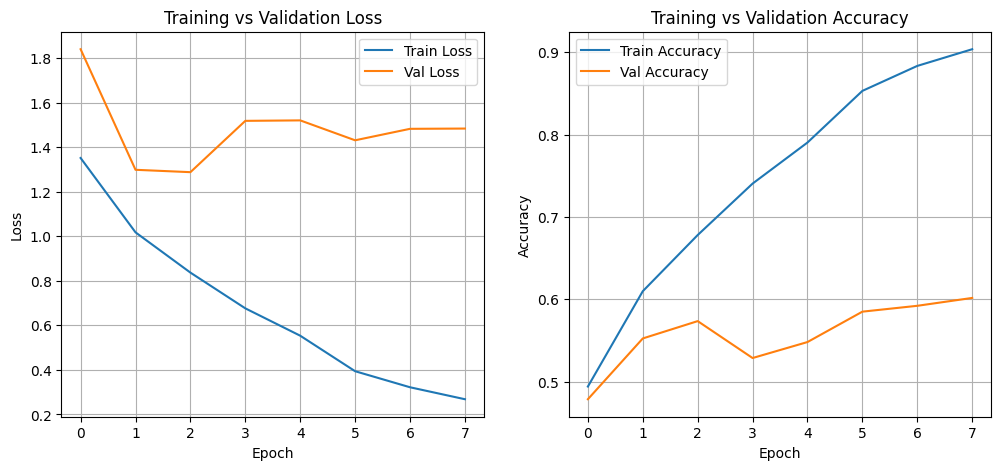

In [42]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_ft.history["loss"], label="Train Loss")
plt.plot(history_ft.history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid()

plt.subplot(1,2,2)
plt.plot(history_ft.history["accuracy"], label="Train Accuracy")
plt.plot(history_ft.history["val_accuracy"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid()

plt.show()


## Confusion Matrix


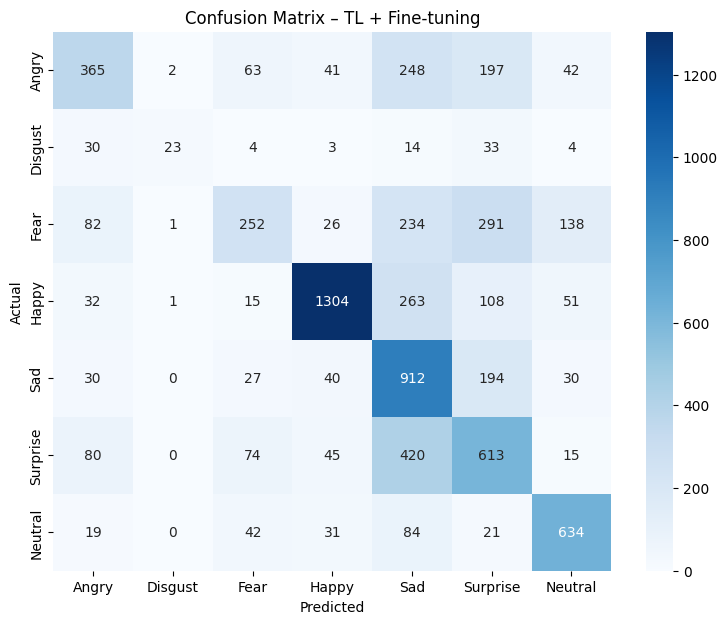

In [43]:
labels = ["Angry","Disgust","Fear","Happy","Sad","Surprise","Neutral"]

cm = confusion_matrix(y_true, y_pred)
cm_df = pd.DataFrame(cm, index=labels, columns=labels)

plt.figure(figsize=(9,7))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix – TL + Fine-tuning")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()


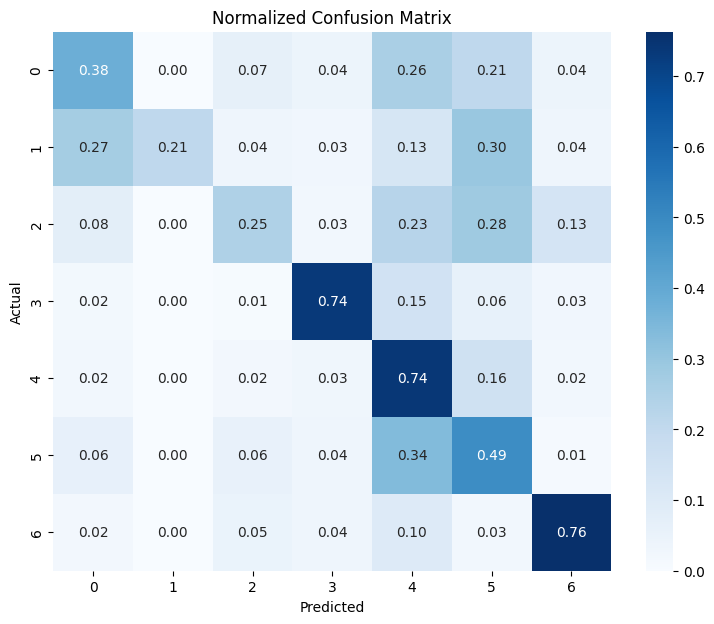

In [44]:
cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(9,7))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues")
plt.title("Normalized Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()


## Classification Report


In [45]:
print(classification_report(
    y_true,
    y_pred,
    target_names=labels,
    digits=3
))

              precision    recall  f1-score   support

       Angry      0.572     0.381     0.457       958
     Disgust      0.852     0.207     0.333       111
        Fear      0.528     0.246     0.336      1024
       Happy      0.875     0.735     0.799      1774
         Sad      0.419     0.740     0.535      1233
    Surprise      0.421     0.492     0.453      1247
     Neutral      0.694     0.763     0.727       831

    accuracy                          0.572      7178
   macro avg      0.623     0.509     0.520      7178
weighted avg      0.607     0.572     0.566      7178



In [46]:
p, r, f1, s = precision_recall_fscore_support(y_true, y_pred)

for i, lab in enumerate(labels):
    print(f"{lab:10s}  F1: {f1[i]:.3f}")


Angry       F1: 0.457
Disgust     F1: 0.333
Fear        F1: 0.336
Happy       F1: 0.799
Sad         F1: 0.535
Surprise    F1: 0.453
Neutral     F1: 0.727


## Error Analysis


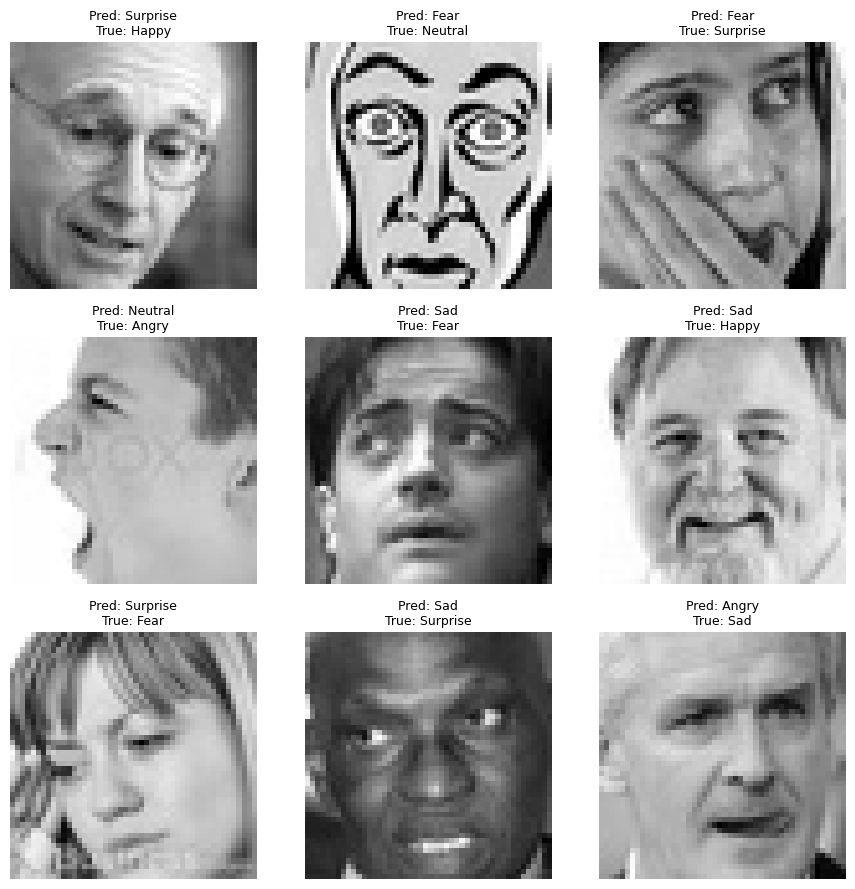

In [47]:
wrong = np.where(y_true != y_pred)[0]
sample = random.sample(list(wrong), 9)

test_images = list(test_ds.unbatch())

plt.figure(figsize=(9,9))

for i, idx in enumerate(sample):
    img, true_lab = test_images[idx]
    pred_lab = y_pred[idx]

    plt.subplot(3,3,i+1)
    plt.imshow(img.numpy().squeeze(), cmap="gray")
    plt.title(
        f"Pred: {labels[pred_lab]}\nTrue: {labels[np.argmax(true_lab)]}",
        fontsize=9
    )
    plt.axis("off")

plt.tight_layout()
plt.show()


## Confidence Analysis


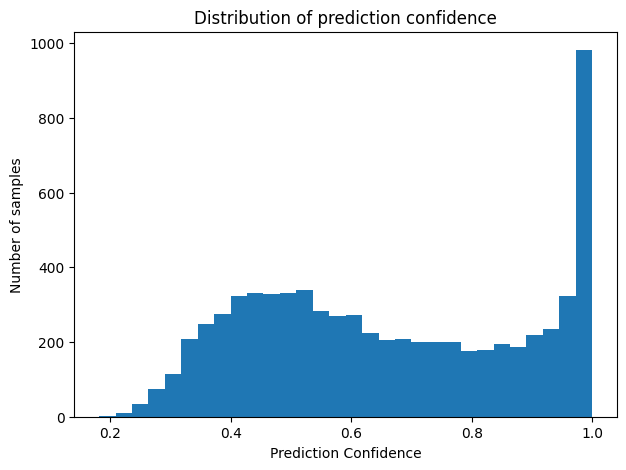

In [48]:
confidences = np.max(y_prob, axis=1)

plt.figure(figsize=(7,5))
plt.hist(confidences, bins=30)
plt.xlabel("Prediction Confidence")
plt.ylabel("Number of samples")
plt.title("Distribution of prediction confidence")
plt.show()


## Top-2 Accuracy


In [49]:
top2 = np.argsort(y_prob, axis=1)[:, -2:]
top2_acc = np.mean([y_true[i] in top2[i] for i in range(len(y_true))])
print("Top-2 accuracy:", top2_acc)


Top-2 accuracy: 0.7659515185288381


## Model Comparison


In [50]:
print("CNN baseline:", max(history.history["val_accuracy"]))
print("CNN + Label smoothing:", max(history_ls.history["val_accuracy"]))
print("TL frozen:", max(history_tl.history["val_accuracy"]))
print("TL + Fine-tuning:", max(history_ft.history["val_accuracy"]))


CNN baseline: 0.596937358379364
CNN + Label smoothing: 0.6002187728881836
TL frozen: 0.5343177318572998
TL + Fine-tuning: 0.6015859842300415


In [52]:
print("Final TL+FT Test Accuracy:", model_tl.evaluate(test_ds_tl)[1])


113/113 ━━━━━━━━━━━━━━━━━━━━ 21s 188ms/step - accuracy: 0.4638 - loss: 1.6010
Final TL+FT Test Accuracy: 0.5716077089309692


| Model | Best Validation Accuracy |
|-----|-------------------------|
| CNN baseline | 0.597 |
| CNN + Label smoothing | 0.600 |
| Transfer Learning (frozen) | 0.534 |
| Transfer Learning + Fine-tuning | 0.602 |

## Conclusions


The highest validation accuracy was achieved by the Transfer Learning model with fine-tuning (60.2%), slightly outperforming both the baseline CNN and the CNN with label smoothing. Transfer learning without fine-tuning resulted in significantly worse performance, which indicates that adapting the pretrained backbone to the target domain is essential.

Per-class analysis shows that the model performs best for the Happy and Neutral emotions, while Disgust and Fear remain the most challenging classes. This behavior is consistent with findings reported in the literature for the FER2013 dataset.

The Top-2 accuracy of 76.6% suggests that in most cases the correct emotion is contained among the two most confident predictions, which highlights the potential usefulness of the system in practical applications.

The distribution of prediction confidence indicates that the model is highly confident for easy samples, while lower confidence values are associated with visually ambiguous facial expressions.

Overall, the results confirm that transfer learning combined with fine-tuning is an effective approach for facial emotion recognition.
